# Relevant Weather for coffee production - Brazil and Colombia

In [68]:
# set paths
path_fold = "C:/Users/canzolbr/Documents/GitHub/Forecasting-World-Coffee-Prices/Data/"
path_img  = "C:/Users/canzolbr/Documents/GitHub/Forecasting-World-Coffee-Prices/Images/"

#### Load coffee production shares by region

In [11]:
# load production shares for Brazil and Colombia
import pandas as pd

dfs_br = pd.read_csv(path_fold + "br_prod_shares.csv")
dfs_co = pd.read_csv(path_fold + "col_prod_shares.csv")

In [6]:
dfs_br.columns

Index(['Unnamed: 0', 'division', 'prod_val', 'prod_share', 'state_name'], dtype='object')

In [12]:
# homogenize names and columns
dfs_br = dfs_br[['state_name','prod_share']]
dfs_co = dfs_co[['depto','prod_share']]
dfs_co = dfs_co.rename(columns = {'depto':'state_name'})

In [13]:
# concat both databases
dfs_br['country'] = 'Brazil'
dfs_co['country'] = 'Colombia'

dfs = pd.concat([dfs_br,dfs_co],axis=0)

#### Load SPEI panel data

In [16]:
!pip install pyreadr

   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.4 MB ? eta -:--:--
   ----------------- ---------------------- 1.0/2.4 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 2.4/2.4 MB 4.8 MB/s  0:00:00


In [27]:
import pyreadr
dfw = pyreadr.read_r(path_fold + "Weather/spei.Rdata")
dfw = dfw['df']

In [29]:
dfw.columns

Index(['date', 'month', 'state_code', 'state_name', 'year', 'yyyymm', '.geo',
       'precip_mm', 't2m_c', 'country', 'lat', 'lon', 'spei_3', 'spei_6',
       'spei_12'],
      dtype='object')

In [31]:
# subset relevant columns
dfw = dfw[['date','year','month','yyyymm','state_name','country','spei_3','spei_6','spei_12']]

In [33]:
# combine production shares and weather data
df = pd.merge(dfs,dfw,how='inner',on=('state_name','country'))

In [47]:
# compute average SPEI for each country
import numpy as np

wm = lambda x: np.average(x,weights = df.loc[x.index,'prod_share'])
dfg = df.groupby(['country','year','month']).agg(spei3_ave = ('spei_3',wm),
                                           spei6_ave = ('spei_6',wm),
                                           spei12_ave = ('spei_12',wm))

In [48]:
dfg = dfg.reset_index()

In [53]:
dfg['date_t'] = pd.to_datetime(dict(year = dfg['year'],
                                    month= dfg['month'],
                                    day=1))

#### Graph SPEI values for Brazil and Colombia

In [ ]:
#!pip install seaborn

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

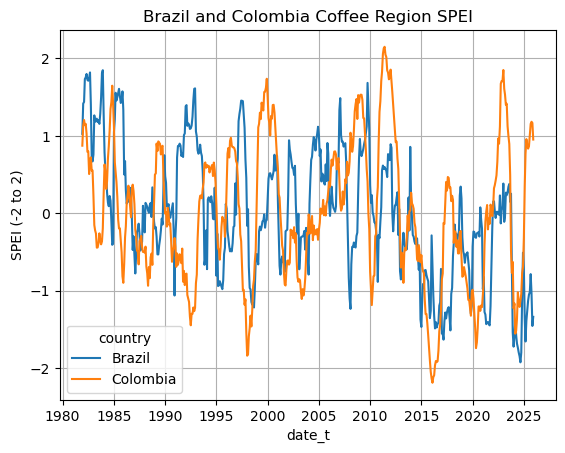

In [69]:
sns.lineplot(dfg,x = 'date_t', y = 'spei12_ave',hue='country')
plt.title('Brazil and Colombia Coffee Region SPEI')
plt.ylabel('SPEI (-2 to 2)')
plt.grid()
plt.savefig(path_img + "spei_coffee_region.png")

#### Compute regional SPEI as a weighted average beween 2 indices

Brazil global production ~ 40 million bags   (73%)
Colombia global production ~ 12 million bags (23%)

In [72]:
# include this shares in the weather index
dfg['prod_share'] = 0.73
dfg.loc[dfg['country']=='Colombia','prod_share']=0.23

In [74]:
wm2 = lambda x: np.average(x,weights = dfg.loc[x.index,'prod_share'])

In [75]:
df_fin = dfg.groupby(['year','month']).agg(spei3  = ('spei3_ave',wm2),
                                           spei6  = ('spei6_ave',wm2),
                                           spei12 = ('spei12_ave',wm2))

In [77]:
df_fin = df_fin.reset_index()

In [78]:
df_fin['date_t'] = pd.to_datetime(dict(year = df_fin['year'],
                                    month= df_fin['month'],
                                    day=1))

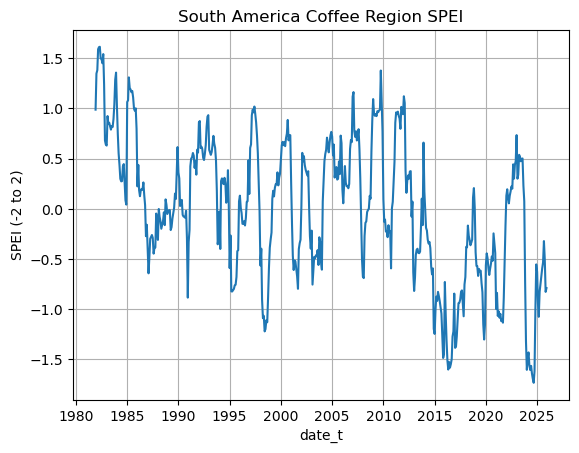

In [79]:
sns.lineplot(df_fin,x = 'date_t', y = 'spei12')
plt.title('South America Coffee Region SPEI')
plt.ylabel('SPEI (-2 to 2)')
plt.grid()
plt.savefig(path_img + "spei_coffee_region_combine.png")

In [81]:
# save  database
df_fin.to_csv(path_fold + "spei_agg.csv")